# Importing Libraries and Functions

In [477]:
# Import libraries
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path
from adjustText import adjust_text

# Import functions from src/features.py
sys.path.append(
    str(Path().resolve().parent)
)

from src.features import (
    get_match_result,
    goal_diff,
    add_position_group,
    team_rating,
    assign_tournament_weight
)

# Load Data

In [478]:
# Load Cleaned Datasets
results = pd.read_csv("../data/processed/results_clean.csv")
wc2026_draw = pd.read_csv("../data/processed/wc2026_draw_clean.csv")
players = pd.read_csv("../data/processed/players_clean.csv")
elo_ratings = pd.read_csv("../data/processed/elo_clean.csv")
wc2026_matches = pd.read_csv("../data/processed/wc2026_matches.csv")

In [479]:
results["date"] = pd.to_datetime(results["date"])
elo_ratings["rank_date"] = pd.to_datetime(elo_ratings["rank_date"])

# Features
## Team Ratings 
### 1. Squad Rating
The average rating of the 26 person squad (the maximum number of players in a squad) for each country.

In [480]:
squad_requirements = { # General squad requirements
    "GK": 3,
    "DEF": 9,
    "MID": 7,
    "FWD": 7
}

# Generating squad ratings for all countries based on top players in each position group, with fill rating for missing players
squad_ratings = team_rating(players, requirements=squad_requirements, rating_name="squad_rating")
squad_ratings.sort_values(["avg_rating", "team_size"], ascending=[False, False])

,country,avg_rating,team_size,missing_players
7,France,84.576923,26,0
6,Spain,84.230769,26,0
12,Brazil,83.615385,26,0
0,England,83.461538,26,0
2,Germany,83.153846,26,0
5,Argentina,82.115385,26,0
8,Portugal,81.961538,26,0
11,Netherlands,81.730769,26,0
13,Belgium,80.115385,26,0
1,Uruguay,78.153846,26,0


In [481]:
# Ensuring that all countries have a squad rating
print(len(squad_ratings))

48


### 2. Top 11 Rating

The average rating of the top 11 players in the squad for each country.

In [482]:
top11_requirements = { # 4-3-3 formation as estimate for starting 11 requirements
    "GK": 1,
    "DEF": 4,
    "MID": 3,
    "FWD": 3
}

# Generating top 11 ratings for all countries based on top players in each position group, with fill rating for missing players
top11_ratings = team_rating(players, requirements=top11_requirements, rating_name="top11_rating")
top11_ratings.sort_values(["avg_rating", "team_size"], ascending=[False, False])

,country,avg_rating,team_size,missing_players
7,France,86.636364,11,0
12,Brazil,86.090909,11,0
0,England,85.727273,11,0
6,Spain,85.636364,11,0
2,Germany,85.181818,11,0
8,Portugal,84.636364,11,0
5,Argentina,84.454545,11,0
11,Netherlands,83.363636,11,0
13,Belgium,82.363636,11,0
3,Morocco,81.000000,11,0


In [483]:
# Ensuring that all countries have a top 11 rating
print(len(top11_ratings))

48


To prevent data leakage, the squad rating and top 11 rating are not used for model training, only for use in predicting the 2026 World Cup.

## Elo Features

### Preparing the data for merging

In [484]:
# Standardising country names between results and elo datasets
country_map = {
    "Brunei Darussalam": "Brunei",
    "Chinese Taipei": "Taiwan",
    "Hong Kong, China": "Hong Kong",
    "Korea DPR": "North Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "St Kitts and Nevis": "Saint Kitts and Nevis",
    "St Lucia": "Saint Lucia",
    "St Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "The Gambia": "Gambia",
    "US Virgin Islands": "United States Virgin Islands"
}

# Apply country name mapping to elo dataset
elo_ratings["country_full"] = elo_ratings["country_full"].replace(country_map)

In [485]:
# Filter results to only include matches between countries present in the Elo ratings dataset as some countries are obsolete and not present in elo dataset
valid_countries = set(elo_ratings["country_full"])
results = results[results["home_team"].isin(valid_countries) & results["away_team"].isin(valid_countries)]

In [486]:
# Checking for any remaining discrepancies in country names between results and elo datasets
results_countries = set(results["home_team"]).union(
    set(results["away_team"])
)

elo_countries = set(elo_ratings["country_full"])

print("In results but not elo:")
print(sorted(results_countries - elo_countries))

print("\nIn elo but not results:")
print(sorted(elo_countries - results_countries))

In results but not elo:
[]

In elo but not results:
['Netherlands Antilles', 'Serbia and Montenegro', 'Zaire']


In [487]:
# Sorting by date for good measure, though it should already be sorted
elo_ratings = elo_ratings.sort_values("rank_date")
results = results.sort_values("date")

# Home team Elo ratings
home_elo = elo_ratings.rename(columns={
    "country_full": "home_team",
    "total_points": "home_elo"
})
# Merge home team Elo ratings with results
results = pd.merge_asof(
    results.sort_values("date"),
    home_elo.sort_values("rank_date"),
    left_on="date",
    right_on="rank_date",
    by="home_team",
    direction="backward"
)

# Away team Elo ratings
away_elo = elo_ratings.rename(columns={
    "country_full": "away_team",
    "total_points": "away_elo"
})

# Merge away team Elo ratings with results
results = pd.merge_asof(
    results.sort_values("date"),
    away_elo.sort_values("rank_date"),
    left_on="date",
    right_on="rank_date",
    by="away_team",
    direction="backward"
)

### Creating Elo Features

### 1. Elo Difference

The difference in elo rating between home and away teams at the time of each match.

In [488]:
results["elo_diff"] = results["home_elo"] - results["away_elo"]

### 2. Absolute Elo Difference

In [489]:
results["abs_elo_diff"] = results["elo_diff"].abs()

In [490]:
# Checking
results[["date", "home_team", "away_team", "home_elo", "away_elo", "elo_diff"]].sample(10)

,date,home_team,away_team,home_elo,away_elo,elo_diff
9583,1976-02-01,Japan,Bulgaria,NaN,NaN,NaN
10106,1977-04-27,Scotland,Sweden,NaN,NaN,NaN
23139,2000-06-29,Ecuador,Peru,469.0,567.0,-98.0
22097,1999-06-08,Serbia,Malta,NaN,271.0,NaN
35495,2014-06-14,Ivory Coast,Japan,809.0,626.0,183.0
6398,1967-01-25,Paraguay,Bolivia,NaN,NaN,NaN
14703,1987-10-17,Switzerland,Italy,NaN,NaN,NaN
31233,2009-09-05,Denmark,Portugal,892.0,880.0,12.0
12248,1982-05-01,Cameroon,Senegal,NaN,NaN,NaN
8575,1973-05-27,Tanzania,Mauritius,NaN,NaN,NaN


## Recent Form Features

### 1. Win rate of the last 10 matches
### 2. Draw rate of the last 10 matches

In [491]:
# Creating home dataset
home_df = results[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

# Rename columns
home_df["team"] = home_df["home_team"]
home_df["opponent"] = home_df["away_team"]

# Add win column for home team
home_df["win"] = (
    home_df["home_score"]
    > home_df["away_score"]
).astype(int)

# Add draw column for home team
home_df["draw"] = (
    home_df["home_score"]
    == home_df["away_score"]
).astype(int)

home_df = home_df[["date", "team", "opponent", "win", "draw"]]

In [492]:
# Creating away dataset
away_df = results[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

# Rename columns
away_df["team"] = away_df["away_team"]
away_df["opponent"] = away_df["home_team"]

# Add win column for away team
away_df["win"] = (
    away_df["away_score"]
    > away_df["home_score"]
).astype(int)

# Add draw column for away team
away_df["draw"] = (
    away_df["away_score"]
    == away_df["home_score"]
).astype(int)

away_df = away_df[["date", "team", "opponent", "win", "draw"]]

In [493]:
team_matches = pd.concat([home_df, away_df])

team_matches = team_matches.sort_values(["team", "date"])

team_matches["recent_win_rate"] = (
    team_matches
    .groupby("team")["win"]
    .transform(
        lambda x:
        x.shift(1).rolling(10, min_periods=1).mean() # last 10 matches win rate, excluding current match
    )
)

team_matches["recent_draw_rate"] = (
    team_matches
    .groupby("team")["draw"]
    .transform(
        lambda x:
        x.shift(1).rolling(10, min_periods=1).mean() # last 10 matches draw rate, excluding current match
    )
)

team_matches

,date,team,opponent,win,draw,recent_win_rate,recent_draw_rate
2475,1941-08-10,Afghanistan,India,0,0,NaN,NaN
3284,1950-10-26,Afghanistan,Iran,0,0,0.0,0.0
3319,1951-03-07,Afghanistan,India,0,0,0.0,0.0
3323,1951-03-09,Afghanistan,Japan,0,0,0.0,0.0
3715,1954-05-04,Afghanistan,South Korea,0,0,0.0,0.0
...,...,...,...,...,...,...,...
46025,2025-12-26,Zimbabwe,Angola,0,1,0.1,0.3
46037,2025-12-29,Zimbabwe,South Africa,0,0,0.1,0.3
46133,2026-03-28,Zimbabwe,Botswana,1,0,0.1,0.3
46209,2026-05-26,Zimbabwe,Nigeria,0,0,0.2,0.2


In [494]:
# Creating home team and away team recent win rate features by merging with results dataframe

# df of home team's recent form
home_form = team_matches[[
    "date",
    "team",
    "recent_win_rate",
    "recent_draw_rate"
]].rename(columns={
    "team": "home_team",
    "recent_win_rate": "home_recent_win_rate",
    "recent_draw_rate": "home_recent_draw_rate"
})

# df of away team's recent form
away_form = team_matches[[
    "date",
    "team",
    "recent_win_rate",
    "recent_draw_rate"
]].rename(columns={
    "team": "away_team",
    "recent_win_rate": "away_recent_win_rate",
    "recent_draw_rate": "away_recent_draw_rate"
})

# Merging home and away recent form features with results df
results = results.merge(
    home_form,
    on=["date", "home_team"],
    how="left"
)

results = results.merge(
    away_form,
    on=["date", "away_team"],
    how="left"
)

results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_result,...,previous_points_y,rank_change_y,confederation_y,rank_date_y,elo_diff,abs_elo_diff,home_recent_win_rate,home_recent_draw_rate,away_recent_win_rate,away_recent_draw_rate
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,NaN,NaN,NaN,NaT,NaN,NaN,0.000000,1.000000,0.000000,1.000000
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,NaN,NaN,NaN,NaT,NaN,NaN,0.000000,0.500000,0.500000,0.500000
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,NaN,NaN,NaN,NaT,NaN,NaN,0.333333,0.333333,0.333333,0.333333
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,NaN,NaN,NaN,NaT,NaN,NaN,0.250000,0.500000,0.250000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46543,2026-06-03,Gibraltar,British Virgin Islands,4,0,Friendly,Gibraltar,Gibraltar,False,home_win,...,776.54,-9.0,CONCACAF,2026-04-01,275.0,275.0,0.000000,0.000000,0.300000,0.200000
46544,2026-06-03,Albania,Israel,0,1,Friendly,Tirana,Albania,False,away_win,...,1328.14,18.0,UEFA,2026-04-01,12.0,12.0,0.500000,0.200000,0.400000,0.200000
46545,2026-06-03,DR Congo,Denmark,0,0,Friendly,Liège,Belgium,True,draw,...,1616.75,3.0,UEFA,2026-04-01,-215.0,215.0,0.700000,0.200000,0.600000,0.300000
46546,2026-06-03,South Korea,El Salvador,1,0,Friendly,Provo,United States,True,home_win,...,1226.65,-22.0,CONCACAF,2026-04-01,411.0,411.0,0.600000,0.100000,0.100000,0.200000


### 3. Average goals scored in the last 10 matches
### 4. Total goals scored in the last 10 matches
### 5. Total goals conceded in the last 10 matches

In [495]:
# Creating home team and away team average goals scored in the last 10 matches
home_matches = results[[
    "date",
    "home_team",
    "home_score",
    "away_score"
]].copy()

home_matches["team"] = home_matches["home_team"]
home_matches["goals_scored"] = home_matches["home_score"]
home_matches["goals_conceded"] = home_matches["away_score"]

away_matches = results[[
    "date",
    "away_team",
    "away_score",
    "home_score"
]].copy()

away_matches["team"] = away_matches["away_team"]
away_matches["goals_scored"] = away_matches["away_score"]
away_matches["goals_conceded"] = away_matches["home_score"]

# Combining home and away matches to calculate average goals scored in last 10 matches for each team
team_matches = pd.concat([
    home_matches[["date", "team", "goals_scored", "goals_conceded"]],
    away_matches[["date", "team", "goals_scored", "goals_conceded"]]
])

# Sorting by team and date to ensure correct order for rolling calculation
team_matches = team_matches.sort_values(["team", "date"])

# Rolling window calculation for average goals scored in last 10 matches, excluding current match
team_matches["avg_goals_last10"] = (
    team_matches
    .groupby("team")["goals_scored"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

# Rolling window calculation for total goals scored in last 10 matches, excluding current match
team_matches["total_goals_last10"] = (
    team_matches
    .groupby("team")["goals_scored"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).sum())  # sum instead of mean
)

# Rolling window calculation for average goals conceded in last 10 matches, excluding current match
team_matches["avg_conceded_last10"] = (
    team_matches
    .groupby("team")["goals_conceded"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

# Rolling window calculation for total goals conceded in last 10 matches, excluding current match
team_matches["total_conceded_last10"] = (
    team_matches
    .groupby("team")["goals_conceded"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).sum())
)

team_matches

,date,team,goals_scored,goals_conceded,avg_goals_last10,total_goals_last10,avg_conceded_last10,total_conceded_last10
2581,1941-08-10,Afghanistan,1,3,NaN,NaN,NaN,NaN
3410,1950-10-26,Afghanistan,0,4,1.000000,1.0,3.000000,3.0
3445,1951-03-07,Afghanistan,0,3,0.500000,1.0,3.500000,7.0
3449,1951-03-09,Afghanistan,0,2,0.333333,1.0,3.333333,10.0
3845,1954-05-04,Afghanistan,2,8,0.250000,1.0,3.000000,12.0
...,...,...,...,...,...,...,...,...
46319,2025-12-26,Zimbabwe,1,1,0.600000,6.0,1.300000,13.0
46331,2025-12-29,Zimbabwe,2,3,0.600000,6.0,1.300000,13.0
46427,2026-03-28,Zimbabwe,3,0,0.800000,8.0,1.400000,14.0
46503,2026-05-26,Zimbabwe,0,2,1.000000,10.0,1.300000,13.0


In [496]:
# Merge back using original home/away context
home_goals = (
    home_matches[["date", "home_team"]]
    .merge(team_matches[["date", "team", "avg_goals_last10", "total_goals_last10", "avg_conceded_last10", "total_conceded_last10"]],
           left_on=["date", "home_team"],
           right_on=["date", "team"],
           how="left")
    .drop_duplicates(subset=["date", "home_team"])
    .rename(columns={"avg_goals_last10": "home_avg_goals_last10", "total_goals_last10": "home_total_goals_last10", "avg_conceded_last10": "home_avg_conceded_last10", "total_conceded_last10": "home_total_conceded_last10"})
)

away_goals = (
    away_matches[["date", "away_team"]]
    .merge(team_matches[["date", "team", "avg_goals_last10", "total_goals_last10", "avg_conceded_last10", "total_conceded_last10"]],
           left_on=["date", "away_team"],
           right_on=["date", "team"],
           how="left")
    .drop_duplicates(subset=["date", "away_team"])
    .rename(columns={"avg_goals_last10": "away_avg_goals_last10", "total_goals_last10": "away_total_goals_last10", "avg_conceded_last10": "away_avg_conceded_last10", "total_conceded_last10": "away_total_conceded_last10"})
)

results = results.merge(
    home_goals[["date", "home_team", "home_avg_goals_last10", "home_total_goals_last10", "home_avg_conceded_last10", "home_total_conceded_last10"]],
    on=["date", "home_team"],
    how="left"
)

results = results.merge(
    away_goals[["date", "away_team", "away_avg_goals_last10", "away_total_goals_last10", "away_avg_conceded_last10", "away_total_conceded_last10"]],
    on=["date", "away_team"],
    how="left"
)

results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_result,...,away_recent_win_rate,away_recent_draw_rate,home_avg_goals_last10,home_total_goals_last10,home_avg_conceded_last10,home_total_conceded_last10,away_avg_goals_last10,away_total_goals_last10,away_avg_conceded_last10,away_total_conceded_last10
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,0.000000,1.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,0.500000,0.500000,1.000000,2.0,2.000000,4.0,2.000000,4.0,1.000000,2.0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,0.333333,0.333333,1.666667,5.0,1.333333,4.0,1.333333,4.0,1.666667,5.0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,0.250000,0.500000,1.500000,6.0,1.750000,7.0,1.750000,7.0,1.500000,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46543,2026-06-03,Gibraltar,British Virgin Islands,4,0,Friendly,Gibraltar,Gibraltar,False,home_win,...,0.300000,0.200000,0.300000,3.0,3.100000,31.0,1.600000,16.0,1.500000,15.0
46544,2026-06-03,Albania,Israel,0,1,Friendly,Tirana,Albania,False,away_win,...,0.400000,0.200000,1.000000,10.0,0.800000,8.0,2.000000,20.0,2.100000,21.0
46545,2026-06-03,DR Congo,Denmark,0,0,Friendly,Liège,Belgium,True,draw,...,0.600000,0.300000,1.200000,12.0,0.300000,3.0,2.900000,29.0,1.000000,10.0
46546,2026-06-03,South Korea,El Salvador,1,0,Friendly,Provo,United States,True,home_win,...,0.100000,0.200000,1.800000,18.0,1.200000,12.0,0.400000,4.0,1.700000,17.0


In [497]:
# Adding difference features
results["recent_form_diff"] = results["home_recent_win_rate"] - results["away_recent_win_rate"]
results["abs_recent_form_diff"] = results["recent_form_diff"].abs()
results["recent_draw_diff"] = results["home_recent_draw_rate"] - results["away_recent_draw_rate"]
results["abs_recent_draw_diff"] = results["recent_draw_diff"].abs()
results["diff_in_avg_goals"] = results["home_avg_goals_last10"] - results["away_avg_goals_last10"]
results["diff_in_total_goals"] = results["home_total_goals_last10"] - results["away_total_goals_last10"]
results["diff_in_avg_conceded"] = results["home_avg_conceded_last10"] - results["away_avg_conceded_last10"]
results["diff_in_total_conceded"] = results["home_total_conceded_last10"] - results["away_total_conceded_last10"]

## Home Team Host Status

In [498]:
results["home_is_host"] = (
    (results["home_team"] == results["country"]) 
).astype(int)

## Tournament Weightage

In [499]:
results["tournament_weight"] = results["tournament"].apply(assign_tournament_weight)

In [500]:
# Checking
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 46548 entries, 0 to 46547
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        46548 non-null  datetime64[us]
 1   home_team                   46548 non-null  str           
 2   away_team                   46548 non-null  str           
 3   home_score                  46548 non-null  int64         
 4   away_score                  46548 non-null  int64         
 5   tournament                  46548 non-null  str           
 6   city                        46548 non-null  str           
 7   country                     46548 non-null  str           
 8   neutral                     46548 non-null  bool          
 9   match_result                46548 non-null  str           
 10  goal_diff                   46548 non-null  int64         
 11  Unnamed: 0_x                28662 non-null  float64       
 12  r

# Creating the master dataset

In [501]:
# Selecting relevant features for modelling
matches = results[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "goal_diff",
    "tournament",
    "country",
    "neutral",
    "home_is_host",
    "home_elo",
    "away_elo",
    "elo_diff",
    "abs_elo_diff",
    "home_recent_win_rate",
    "away_recent_win_rate",
    "recent_form_diff",
    "abs_recent_form_diff",
    "home_recent_draw_rate",
    "away_recent_draw_rate",
    "recent_draw_diff",
    "abs_recent_draw_diff",
    "home_avg_goals_last10",
    "away_avg_goals_last10",
    "diff_in_avg_goals",
    "home_total_goals_last10",
    "away_total_goals_last10",
    "diff_in_total_goals",
    "home_avg_conceded_last10",
    "away_avg_conceded_last10",
    "diff_in_avg_conceded",
    "home_total_conceded_last10",
    "away_total_conceded_last10",
    "diff_in_total_conceded",
    "tournament_weight",
    "match_result"
]]

matches

,date,home_team,away_team,home_score,away_score,goal_diff,tournament,country,neutral,home_is_host,...,away_total_goals_last10,diff_in_total_goals,home_avg_conceded_last10,away_avg_conceded_last10,diff_in_avg_conceded,home_total_conceded_last10,away_total_conceded_last10,diff_in_total_conceded,tournament_weight,match_result
0,1872-11-30,Scotland,England,0,0,0,Friendly,Scotland,False,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,draw
1,1873-03-08,England,Scotland,4,2,2,Friendly,England,False,1,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1,home_win
2,1874-03-07,Scotland,England,2,1,1,Friendly,Scotland,False,1,...,4.0,-2.0,2.000000,1.000000,1.000000,4.0,2.0,2.0,1,home_win
3,1875-03-06,England,Scotland,2,2,0,Friendly,England,False,1,...,4.0,1.0,1.333333,1.666667,-0.333333,4.0,5.0,-1.0,1,draw
4,1876-03-04,Scotland,England,3,0,3,Friendly,Scotland,False,1,...,7.0,-1.0,1.750000,1.500000,0.250000,7.0,6.0,1.0,1,home_win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46543,2026-06-03,Gibraltar,British Virgin Islands,4,0,4,Friendly,Gibraltar,False,1,...,16.0,-13.0,3.100000,1.500000,1.600000,31.0,15.0,16.0,1,home_win
46544,2026-06-03,Albania,Israel,0,1,-1,Friendly,Albania,False,1,...,20.0,-10.0,0.800000,2.100000,-1.300000,8.0,21.0,-13.0,1,away_win
46545,2026-06-03,DR Congo,Denmark,0,0,0,Friendly,Belgium,True,0,...,29.0,-17.0,0.300000,1.000000,-0.700000,3.0,10.0,-7.0,1,draw
46546,2026-06-03,South Korea,El Salvador,1,0,1,Friendly,United States,True,0,...,4.0,14.0,1.200000,1.700000,-0.500000,12.0,17.0,-5.0,1,home_win


In [502]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 46548 entries, 0 to 46547
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        46548 non-null  datetime64[us]
 1   home_team                   46548 non-null  str           
 2   away_team                   46548 non-null  str           
 3   home_score                  46548 non-null  int64         
 4   away_score                  46548 non-null  int64         
 5   goal_diff                   46548 non-null  int64         
 6   tournament                  46548 non-null  str           
 7   country                     46548 non-null  str           
 8   neutral                     46548 non-null  bool          
 9   home_is_host                46548 non-null  int64         
 10  home_elo                    28662 non-null  float64       
 11  away_elo                    28555 non-null  float64       
 12  e

## Handling columns with many NA values

In [503]:
# Finding columns with at least one NA value
matches.isnull().sum()[matches.isnull().sum() > 0]

home_elo                      17886
away_elo                      17993
elo_diff                      18176
abs_elo_diff                  18176
home_recent_win_rate             91
away_recent_win_rate            122
recent_form_diff                184
abs_recent_form_diff            184
home_recent_draw_rate            91
away_recent_draw_rate           122
recent_draw_diff                184
abs_recent_draw_diff            184
home_avg_goals_last10            91
away_avg_goals_last10           122
diff_in_avg_goals               184
home_total_goals_last10          91
away_total_goals_last10         122
diff_in_total_goals             184
home_avg_conceded_last10         91
away_avg_conceded_last10        122
diff_in_avg_conceded            184
home_total_conceded_last10       91
away_total_conceded_last10      122
diff_in_total_conceded          184
dtype: int64

Recent win rate, average goals, total goals scored and total goals conceded inherently have NA values due to the rolling window calculation. 

Elo rating features have a substantial amount of NA values that need to be handled. 

In [504]:
# Check matches per year
matches["year"] = matches["date"].dt.year
print(matches.groupby("year").size())

# Check how many matches post-2000 vs overall
print(f"Post-2000 matches: {len(matches[matches['date'] >= '2000-01-01'])}")
print(f"Total matches: {len(matches)}")

# Check how many World Cup matches post-2000 vs overall
print(f"WC matches post-2000: {len(matches[(matches['date'] >= '2000-01-01') & (matches['tournament'] == 'FIFA World Cup')])}")

year
1872       1
1873       1
1874       1
1875       1
1876       2
        ... 
2022     933
2023     954
2024    1194
2025     960
2026     206
Length: 155, dtype: int64
Post-2000 matches: 23747
Total matches: 46548
WC matches post-2000: 384


Filtering for matches after the year 2000 to reduce the number of missing Elo values while retaining enough data for training and modelling.

In [505]:
# Filter for matches after 2000
matches = matches[matches["date"] >= "2000-01-01"]

# Checking for any remaining NA values after filtering
matches.isnull().sum()[matches.isnull().sum() > 0]

home_elo                       81
away_elo                      101
elo_diff                      182
abs_elo_diff                  182
home_recent_win_rate            3
away_recent_win_rate            1
recent_form_diff                4
abs_recent_form_diff            4
home_recent_draw_rate           3
away_recent_draw_rate           1
recent_draw_diff                4
abs_recent_draw_diff            4
home_avg_goals_last10           3
away_avg_goals_last10           1
diff_in_avg_goals               4
home_total_goals_last10         3
away_total_goals_last10         1
diff_in_total_goals             4
home_avg_conceded_last10        3
away_avg_conceded_last10        1
diff_in_avg_conceded            4
home_total_conceded_last10      3
away_total_conceded_last10      1
diff_in_total_conceded          4
dtype: int64

Since the number of NA values for each column are no longer that large, these rows can be dropped.

In [506]:
# Remove rows with NA values
matches = matches.dropna()

# Checking
print(matches.shape)
print(matches.isnull().sum().sum()) 

(23565, 37)
0


# Exploratory Data Analysis of the Master Dataset

## Correlation between Calculated Features

Correlation Matrix of numerical columns in matches dataset

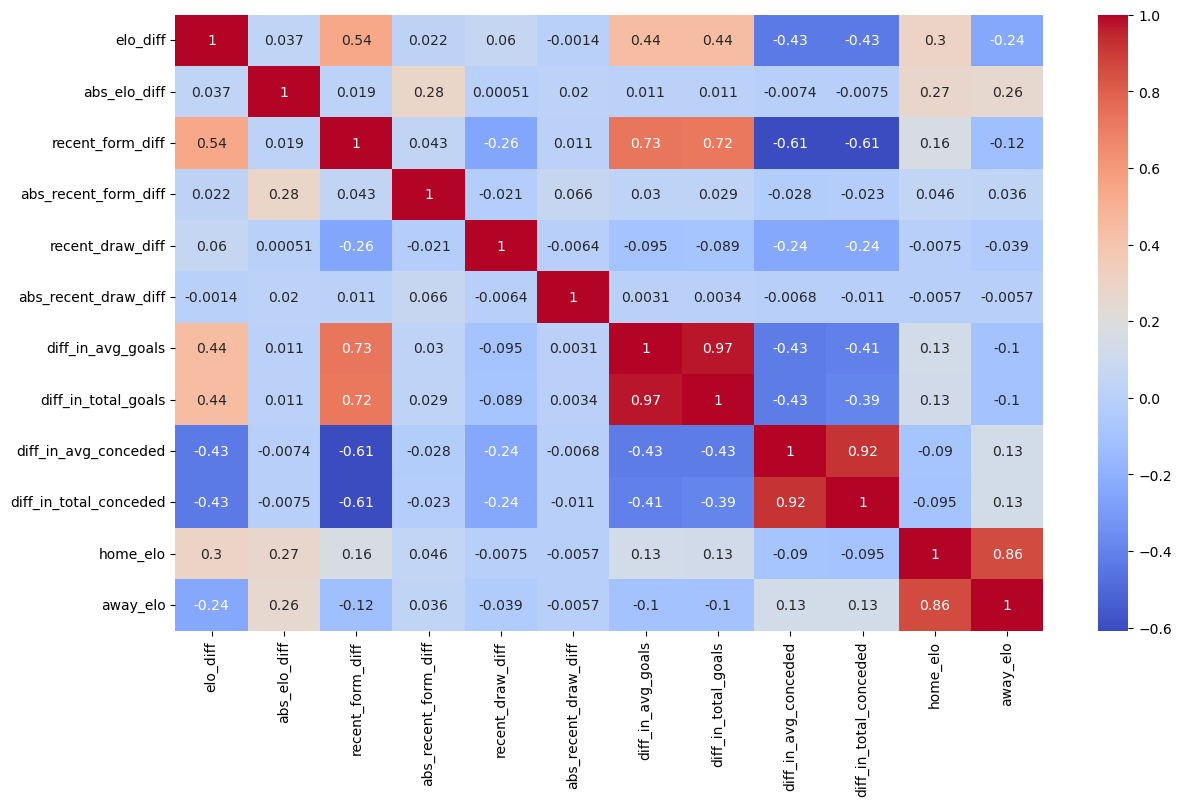

In [507]:
numeric_cols = [
    "elo_diff",
    "abs_elo_diff",
    "recent_form_diff",
    "abs_recent_form_diff",
    "recent_draw_diff",
    "abs_recent_draw_diff",
    "diff_in_avg_goals",
    "diff_in_total_goals",
    "diff_in_avg_conceded",
    "diff_in_total_conceded",
    "home_elo",
    "away_elo"
]

corr = results[numeric_cols].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.show()

In [508]:
# Dropping redundant columns based on the correlation analysis and domain knowledge
matches = matches.drop(columns=[
    "home_elo",
    "away_elo",
    "home_total_goals_last10",
    "away_total_goals_last10",
    "diff_in_total_goals",
    "home_total_conceded_last10",
    "away_total_conceded_last10",
    "diff_in_total_conceded",
    "year"
])

## Correlation between Squad Ratings and Elo Ratings

In [509]:
# Data Preparation

# Add column for squad ratings to World Cup 2026 draw
wc2026_ratings = wc2026_draw.merge(
    squad_ratings[["country", "avg_rating"]],
    on="country",
    how="left"
)

# Filter for latest elo ratings for each country
latest_elo = elo_ratings.sort_values("rank_date").groupby("country_full").tail(1)

# Add column for Elo ratings to World Cup 2026 draw
wc2026_ratings = wc2026_ratings.merge(
    latest_elo[["country_full", "total_points"]],
    left_on="country",
    right_on="country_full",
    how="left"
).drop(columns=["country_full"]).rename(columns={"avg_rating": "squad_rating", "total_points": "elo_rating"})

wc2026_ratings

,country,group,squad_rating,elo_rating
0,Mexico,A,75.576923,1858.0
1,South Africa,A,59.384615,1524.0
2,South Korea,A,73.576923,1752.0
3,Czech Republic,A,75.576923,1726.0
4,Canada,B,72.884615,1784.0
5,Bosnia and Herzegovina,B,72.807692,1594.0
6,Qatar,B,68.307692,1425.0
7,Switzerland,B,77.615385,1889.0
8,Brazil,C,83.615385,1984.0
9,Morocco,C,77.807692,1821.0


Scatter Plot of Elo Ratings against Squad Ratings for countries participating in the 2026 World Cup.

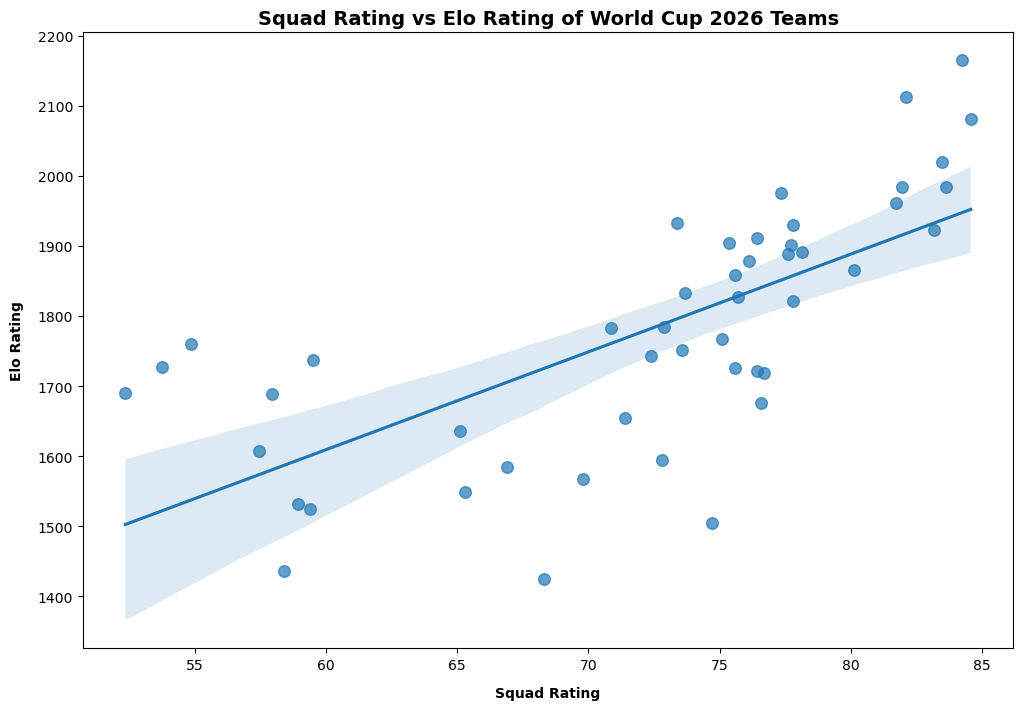

In [510]:
fig, ax = plt.subplots(figsize=(12,8))

sns.regplot(
    data=wc2026_ratings,
    x="squad_rating",
    y="elo_rating",
    scatter_kws={"s": 70, "alpha": 0.7},
    
)

plt.title(
    "Squad Rating vs Elo Rating of World Cup 2026 Teams",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Squad Rating", labelpad=10, fontweight="bold")
plt.ylabel("Elo Rating", labelpad=10, fontweight="bold")
plt.show()

# Create Final Matches Dataset

In [511]:
matches.to_csv("../data/processed/matches.csv", index=False)